#### =============================================================================
## VIRAT KOHLI PERFORMANCE ANALYSIS - BUSINESS INTELLIGENCE PROJECT
#### =============================================================================
#### Author: [vaibhav belekar, darshan shinde , vaibhav sable , aditya daghale]
#### College: [sanghavi college of engineerig]
#### Course: [computer engineering]
#### Date: April 15, 2026
#### =============================================================================

**BUSINESS INTELLIGENCE PROJECT: Virat Kohli Performance Analysis**

**OBJECTIVE:**
This project analyzes Virat Kohli's cricket performance across different formats (Test, ODI, T20) to derive meaningful business intelligence insights that can help:
- Understand performance patterns across formats
- Identify strengths and areas for improvement
- Compare performance metrics strategically
- Provide data-driven recommendations

**KEY BUSINESS QUESTIONS ADDRESSED:**
1. Which format maximizes Kohli's scoring efficiency?
2. How does his performance vary across different formats?
3. What are the key performance drivers for his success?
4. How can we predict future performance trends?
5. What strategic insights can be drawn for team selection?

**TOOLS USED:** Python, Pandas, Matplotlib, Seaborn, Plotly

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("Libraries imported successfully!")
print("Visualization styles configured!")

Libraries imported successfully!
Visualization styles configured!


In [39]:
try:
    df = pd.read_csv("virat_kohli_career_stats.csv")
    print("Data loaded successfully!")
    print(f"Dataset shape: {df.shape}")
    print(f"Columns available: {list(df.columns)}")
except FileNotFoundError:
    print("Error: CSV file not found. Please check the file path.")
    print("Expected file: virat_kohli_career_stats.csv")

print("\nRAW DATA PREVIEW:")
print(df.head())

print("\nDATASET INFORMATION:")
print(df.info())

print("\nBASIC STATISTICS:")
print(df.describe())

Data loaded successfully!
Dataset shape: (6, 14)
Columns available: ['Format', 'Matches', 'Innings', 'Not Outs', 'Runs', 'High Score', 'Average', 'Balls Faced', 'Strike Rate', '100s', '50s', '4s', '6s', 'Catches']

RAW DATA PREVIEW:
   Format  Matches  Innings  Not Outs   Runs High Score  Average  Balls Faced  \
0   Tests      123      210        13   9230       254*    46.85        16608   
1    ODIs      299      287        45  14085        183    58.20        15078   
2   T20Is      125      117        31   4188       122*    48.69         3056   
3      FC      156      259        20  11485       254*    48.05        20526   
4  List A      333      320        48  15527        183    57.08        16614   

   Strike Rate  100s  50s    4s   6s  Catches  
0        55.57    30   31  1027   30      121  
1        93.41    51   73  1318  152      158  
2       137.04     1   38   369  124       54  
3        55.95    37   39  1341   45      152  
4        93.45    55   81  1482  176    

In [40]:
major_formats = ["Tests", "ODIs", "T20Is"]
df_filtered = df[df["Format"].isin(major_formats)].copy()

print("Filtered data for major formats:")
print(f"Original dataset: {df.shape[0]} rows")
print(f"Filtered dataset: {df_filtered.shape[0]} rows")
print(f"Formats included: {major_formats}")

key_metrics = [
    "Format", "Matches", "Innings", "Runs", "Average", "Strike Rate",
    "100s", "50s", "4s", "6s", "High Score", "Balls Faced"
]

df_analysis = df_filtered[key_metrics].reset_index(drop=True)

df_analysis["Runs per Match"] = (df_analysis["Runs"] / df_analysis["Matches"]).round(2)
df_analysis["Runs per Innings"] = (df_analysis["Runs"] / df_analysis["Innings"]).round(2)
df_analysis["Boundary Percentage"] = (((df_analysis["4s"] + df_analysis["6s"]) / (df_analysis["4s"] + df_analysis["6s"] + (df_analysis["Runs"] - 4*df_analysis["4s"] - 6*df_analysis["6s"]))) * 100).round(2)
df_analysis["Big Scores Ratio"] = ((df_analysis["100s"] + df_analysis["50s"]) / df_analysis["Innings"] * 100).round(2)

print("\nENHANCED ANALYSIS DATASET:")
print(df_analysis)

Filtered data for major formats:
Original dataset: 6 rows
Filtered dataset: 3 rows
Formats included: ['Tests', 'ODIs', 'T20Is']

ENHANCED ANALYSIS DATASET:
  Format  Matches  Innings   Runs  Average  Strike Rate  100s  50s    4s   6s  \
0  Tests      123      210   9230    46.85        55.57    30   31  1027   30   
1   ODIs      299      287  14085    58.20        93.41    51   73  1318  152   
2  T20Is      125      117   4188    48.69       137.04     1   38   369  124   

  High Score  Balls Faced  Runs per Match  Runs per Innings  \
0       254*        16608           75.04             43.95   
1        183        15078           47.11             49.08   
2       122*         3056           33.50             35.79   

   Boundary Percentage  Big Scores Ratio  
0                17.62             29.05  
1                15.69             43.21  
2                20.03             33.33  


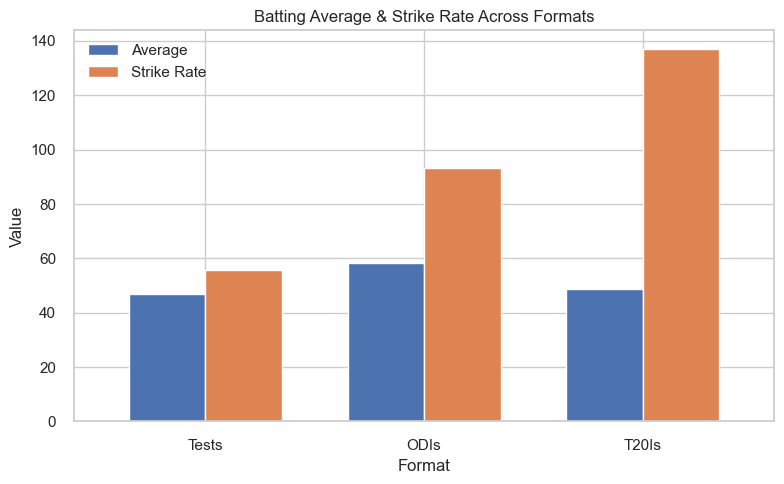

In [41]:
sns.set(style="whitegrid")

fig, ax1 = plt.subplots(figsize=(8, 5))
df_analysis.plot(x="Format", y=["Average", "Strike Rate"], kind="bar", ax=ax1, width=0.7)
plt.title("Batting Average & Strike Rate Across Formats")
plt.xlabel("Format")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.legend(["Average", "Strike Rate"], loc="upper left")
plt.tight_layout()
plt.show()

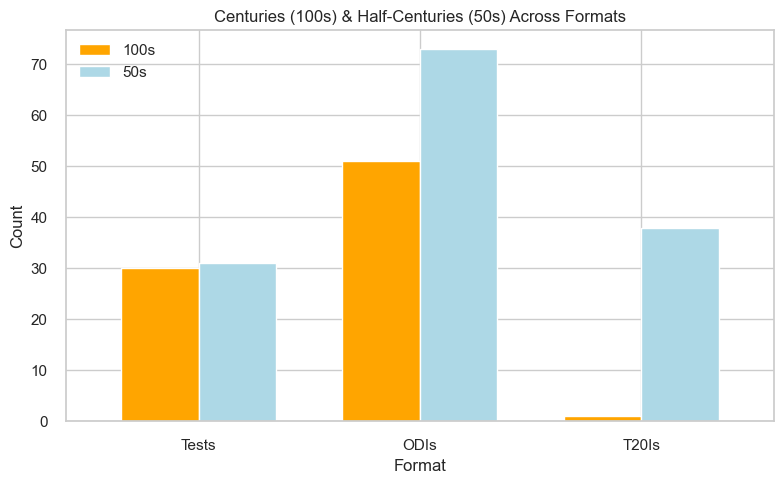

In [42]:
fig, ax2 = plt.subplots(figsize=(8, 5))
df_analysis.plot(x="Format", y=["100s", "50s"], kind="bar", ax=ax2, width=0.7, color=["orange", "lightblue"])
plt.title("Centuries (100s) & Half-Centuries (50s) Across Formats")
plt.xlabel("Format")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(["100s", "50s"], loc="upper left")
plt.tight_layout()
plt.show()

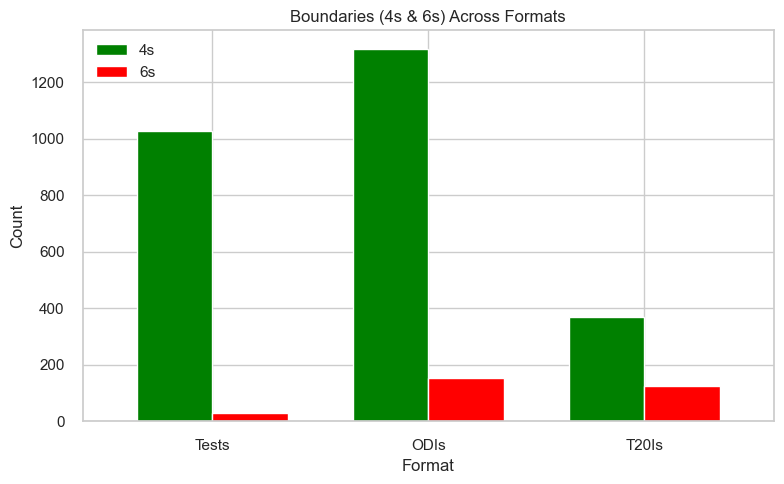

In [43]:
fig, ax3 = plt.subplots(figsize=(8, 5))
df_analysis.plot(x="Format", y=["4s", "6s"], kind="bar", ax=ax3, width=0.7, color=["green", "red"])
plt.title("Boundaries (4s & 6s) Across Formats")
plt.xlabel("Format")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(["4s", "6s"], loc="upper left")
plt.tight_layout()
plt.show()

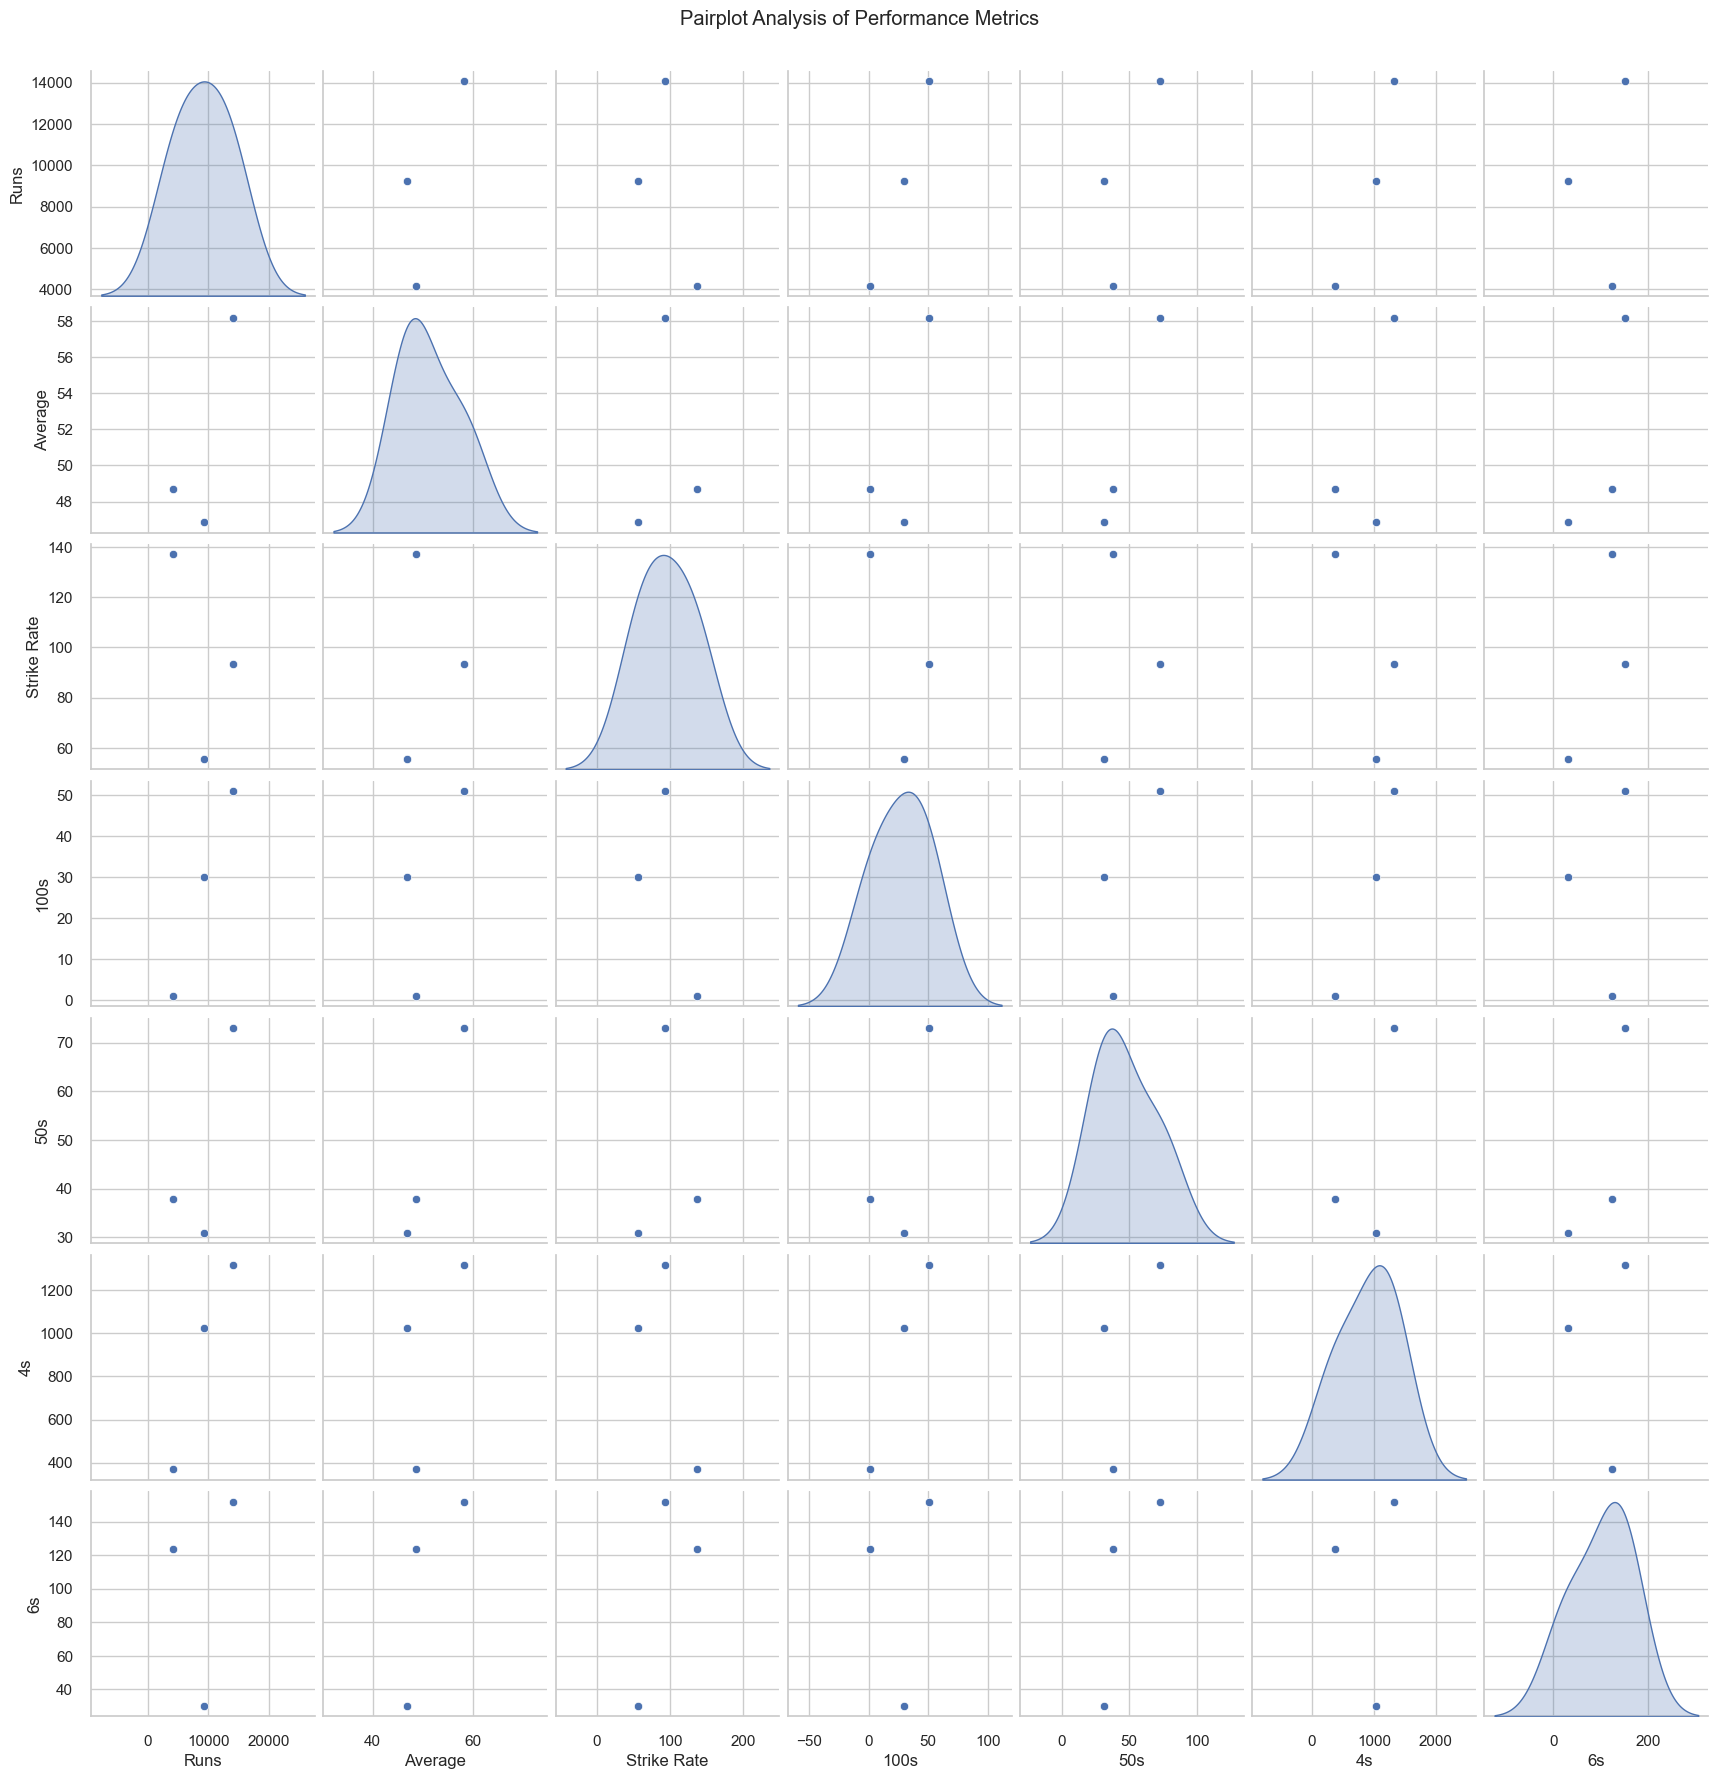

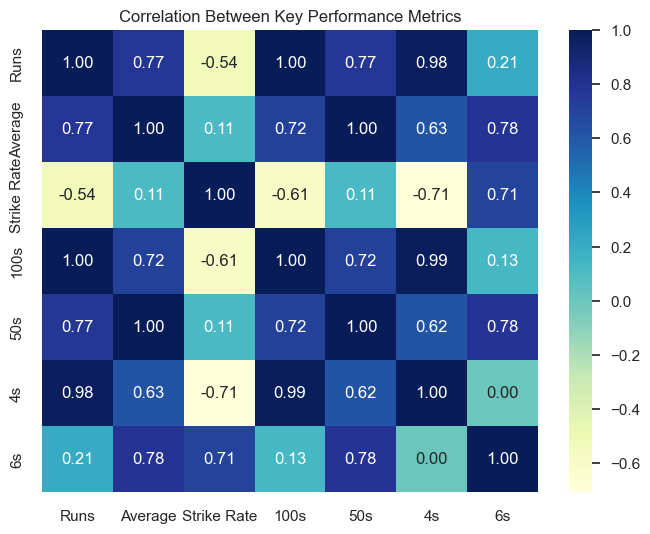

In [44]:
sns.pairplot(df_analysis[["Runs", "Average", "Strike Rate", "100s", "50s", "4s", "6s"]], diag_kind="kde")
plt.suptitle("Pairplot Analysis of Performance Metrics", y=1.02)
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df_analysis[["Runs", "Average", "Strike Rate", "100s", "50s", "4s", "6s"]].corr(), annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Correlation Between Key Performance Metrics")
plt.show()

In [45]:
fig = go.Figure()
fig.add_trace(go.Bar(x=df_analysis["Format"], y=df_analysis["100s"], name="Centuries (100s)", marker_color="orange"))
fig.add_trace(go.Bar(x=df_analysis["Format"], y=df_analysis["50s"], name="Half-Centuries (50s)", marker_color="lightblue"))
fig.update_layout(title="Interactive Centuries & Half-Centuries Across Formats", barmode="group", xaxis_title="Format", yaxis_title="Count")
fig.show()

fig = px.box(df_analysis, x="Format", y="Runs", title="Runs Distribution Across Formats", color="Format")
fig.show()

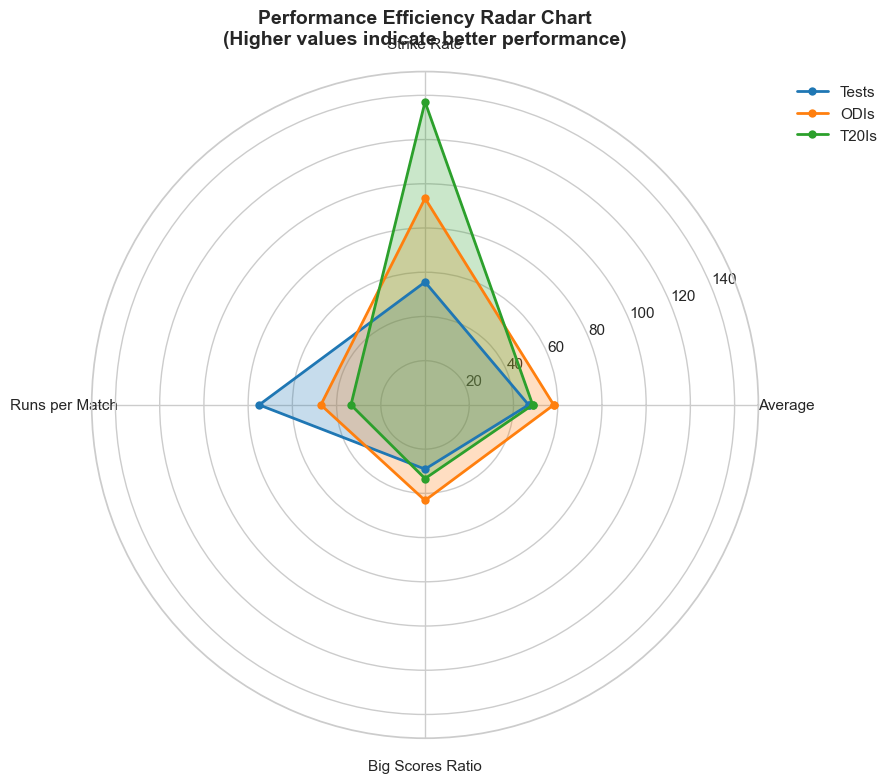

In [46]:
categories = ['Average', 'Strike Rate', 'Runs per Match', 'Big Scores Ratio']
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection='polar'))

angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i, format_name in enumerate(major_formats):
    values = df_analysis[df_analysis['Format'] == format_name][categories].values[0].tolist()
    values += values[:1]

    ax.plot(angles, values, 'o-', linewidth=2, label=format_name, color=colors[i])
    ax.fill(angles, values, alpha=0.25, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, max(df_analysis[categories].max()) * 1.1)
ax.set_title('Performance Efficiency Radar Chart\n(Higher values indicate better performance)', size=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0))
ax.grid(True)

plt.tight_layout()
plt.show()

<Figure size 1500x1000 with 0 Axes>

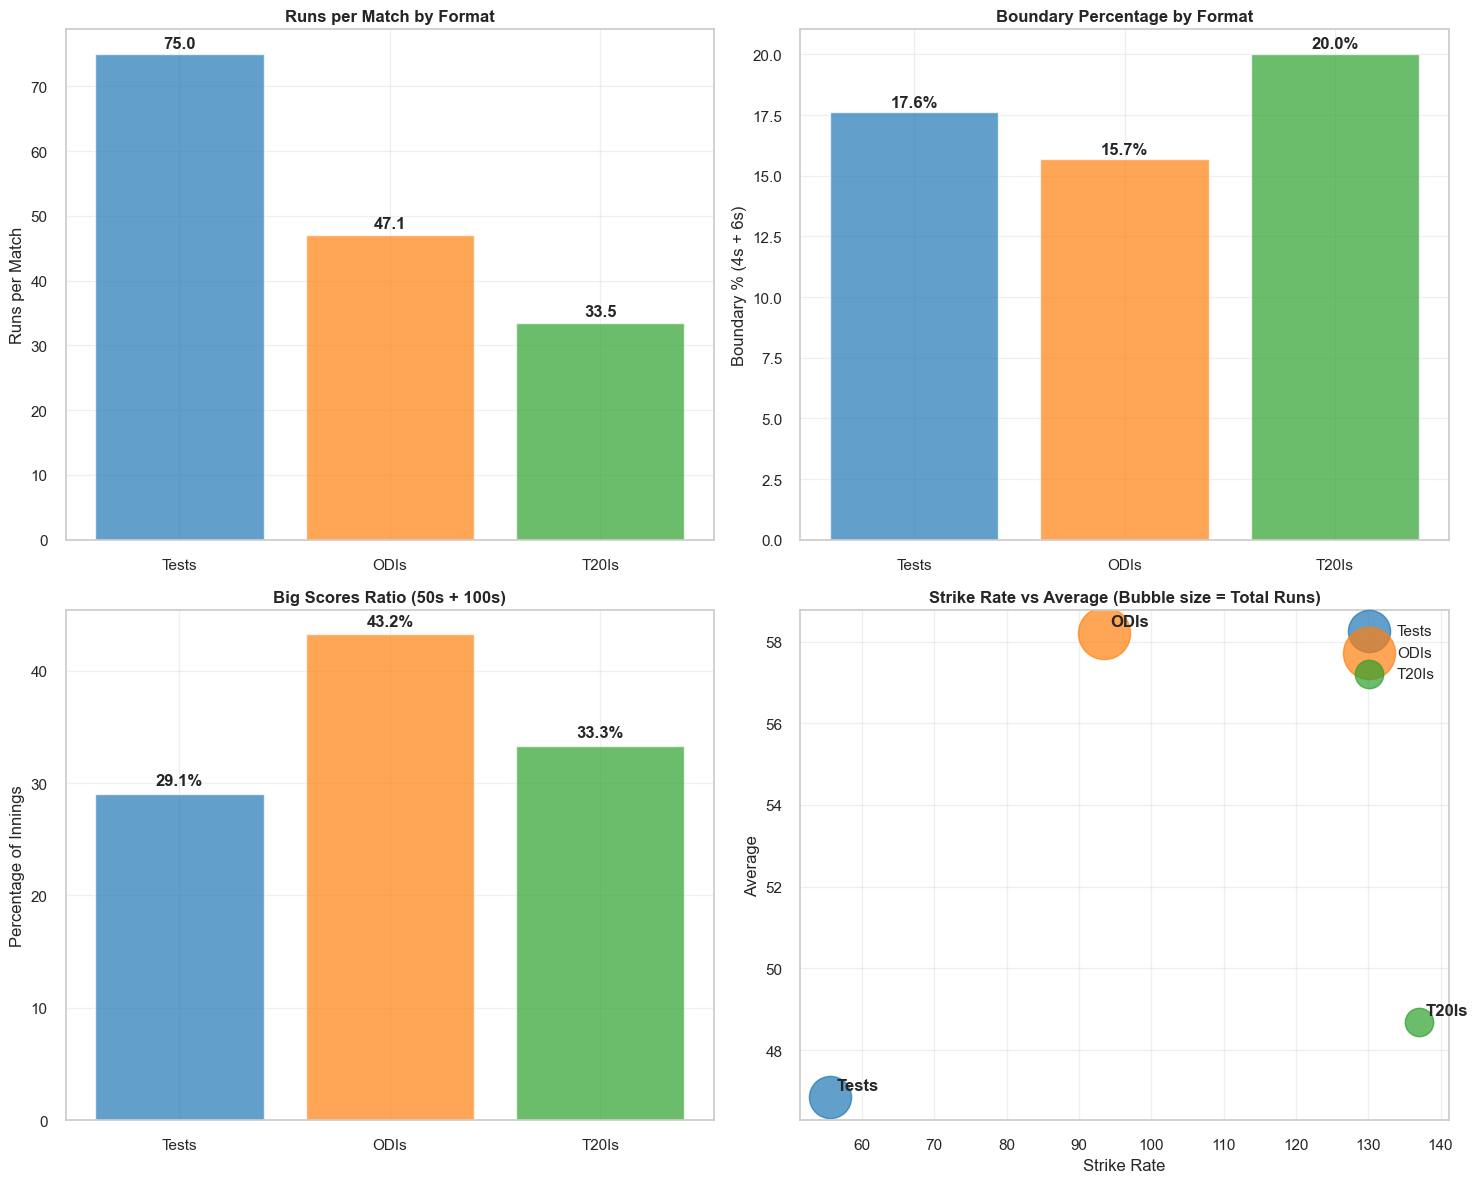

In [47]:
plt.figure(figsize=(15, 10))

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

bars1 = ax1.bar(df_analysis['Format'], df_analysis['Runs per Match'],
                color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
ax1.set_title('Runs per Match by Format', fontweight='bold')
ax1.set_ylabel('Runs per Match')
ax1.grid(True, alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}', ha='center', va='bottom', fontweight='bold')

bars2 = ax2.bar(df_analysis['Format'], df_analysis['Boundary Percentage'],
                color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
ax2.set_title('Boundary Percentage by Format', fontweight='bold')
ax2.set_ylabel('Boundary % (4s + 6s)')
ax2.grid(True, alpha=0.3)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

bars3 = ax3.bar(df_analysis['Format'], df_analysis['Big Scores Ratio'],
                color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
ax3.set_title('Big Scores Ratio (50s + 100s)', fontweight='bold')
ax3.set_ylabel('Percentage of Innings')
ax3.grid(True, alpha=0.3)

for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

for i, row in df_analysis.iterrows():
    ax4.scatter(row['Strike Rate'], row['Average'],
                s=row['Runs']/10, alpha=0.7,
                color=['#1f77b4', '#ff7f0e', '#2ca02c'][i],
                label=row['Format'])
    ax4.annotate(row['Format'], (row['Strike Rate'], row['Average']),
                 xytext=(5, 5), textcoords='offset points', fontweight='bold')

ax4.set_title('Strike Rate vs Average (Bubble size = Total Runs)', fontweight='bold')
ax4.set_xlabel('Strike Rate')
ax4.set_ylabel('Average')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()

In [48]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Performance Overview', 'Scoring Efficiency',
                    'Century Analysis', 'Boundary Distribution'),
    specs=[[{'type': 'scatter'}, {'type': 'bar'}],
           [{'type': 'pie'}, {'type': 'bar'}]]
)

for i, format_name in enumerate(major_formats):
    fig.add_trace(
        go.Scatter(
            x=[df_analysis[df_analysis['Format'] == format_name]['Strike Rate'].values[0]],
            y=[df_analysis[df_analysis['Format'] == format_name]['Average'].values[0]],
            mode='markers+text',
            name=format_name,
            text=[format_name],
            textposition="top center",
            marker=dict(size=df_analysis[df_analysis['Format'] == format_name]['Runs'].values[0]/200,
                       color=['#1f77b4', '#ff7f0e', '#2ca02c'][i]),
            showlegend=True
        ),
        row=1, col=1
    )

fig.update_xaxes(title_text="Strike Rate", row=1, col=1)
fig.update_yaxes(title_text="Average", row=1, col=1)

for i, metric in enumerate(['Runs per Match', 'Runs per Innings']):
    fig.add_trace(
        go.Bar(
            x=df_analysis['Format'],
            y=df_analysis[metric],
            name=metric,
            marker_color=['#1f77b4', '#ff7f0e'][i],
            showlegend=True
        ),
        row=1, col=2
    )

fig.update_xaxes(title_text="Format", row=1, col=2)
fig.update_yaxes(title_text="Runs", row=1, col=2)

total_100s = df_analysis['100s'].sum()
total_50s = df_analysis['50s'].sum()

fig.add_trace(
    go.Pie(
        labels=['Centuries (100s)', 'Half-Centuries (50s)'],
        values=[total_100s, total_50s],
        marker_colors=['#ff6b6b', '#4ecdc4'],
        textinfo='label+percent+value',
        showlegend=False
    ),
    row=2, col=1
)

for i, metric in enumerate(['4s', '6s']):
    fig.add_trace(
        go.Bar(
            x=df_analysis['Format'],
            y=df_analysis[metric],
            name=metric,
            marker_color=['#45b7d1', '#f9ca24'][i],
            showlegend=True
        ),
        row=2, col=2
    )

fig.update_xaxes(title_text="Format", row=2, col=2)
fig.update_yaxes(title_text="Count", row=2, col=2)

fig.update_layout(
    title_text="Interactive Virat Kohli Performance Dashboard",
    title_font_size=20,
    height=800,
    showlegend=True,
    barmode='group'
)

fig.show()

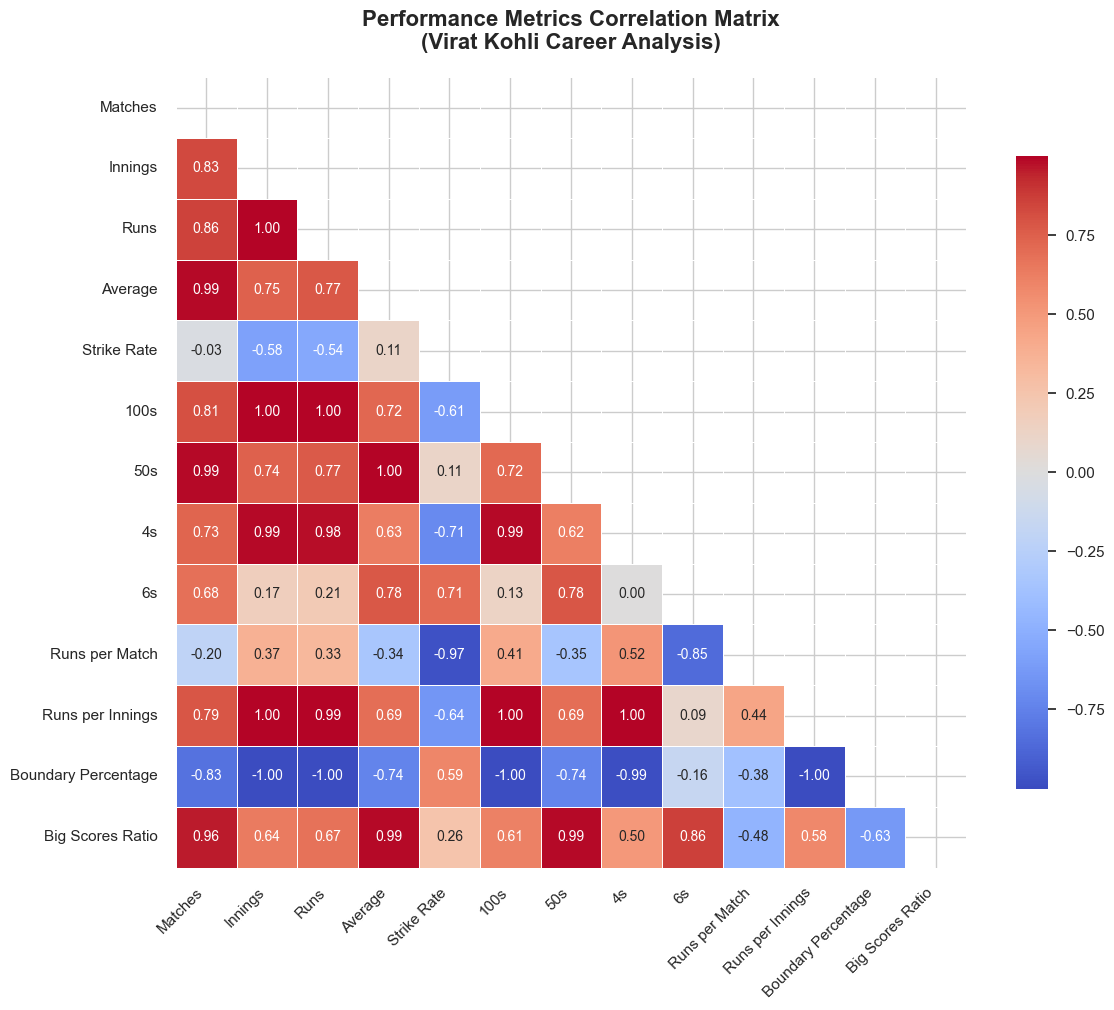

In [49]:
plt.figure(figsize=(12, 10))

numeric_cols = ['Matches', 'Innings', 'Runs', 'Average', 'Strike Rate',
                '100s', '50s', '4s', '6s', 'Runs per Match', 'Runs per Innings',
                'Boundary Percentage', 'Big Scores Ratio']

correlation_matrix = df_analysis[numeric_cols].corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            fmt='.2f', annot_kws={"size": 10})

plt.title('Performance Metrics Correlation Matrix\n(Virat Kohli Career Analysis)',
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

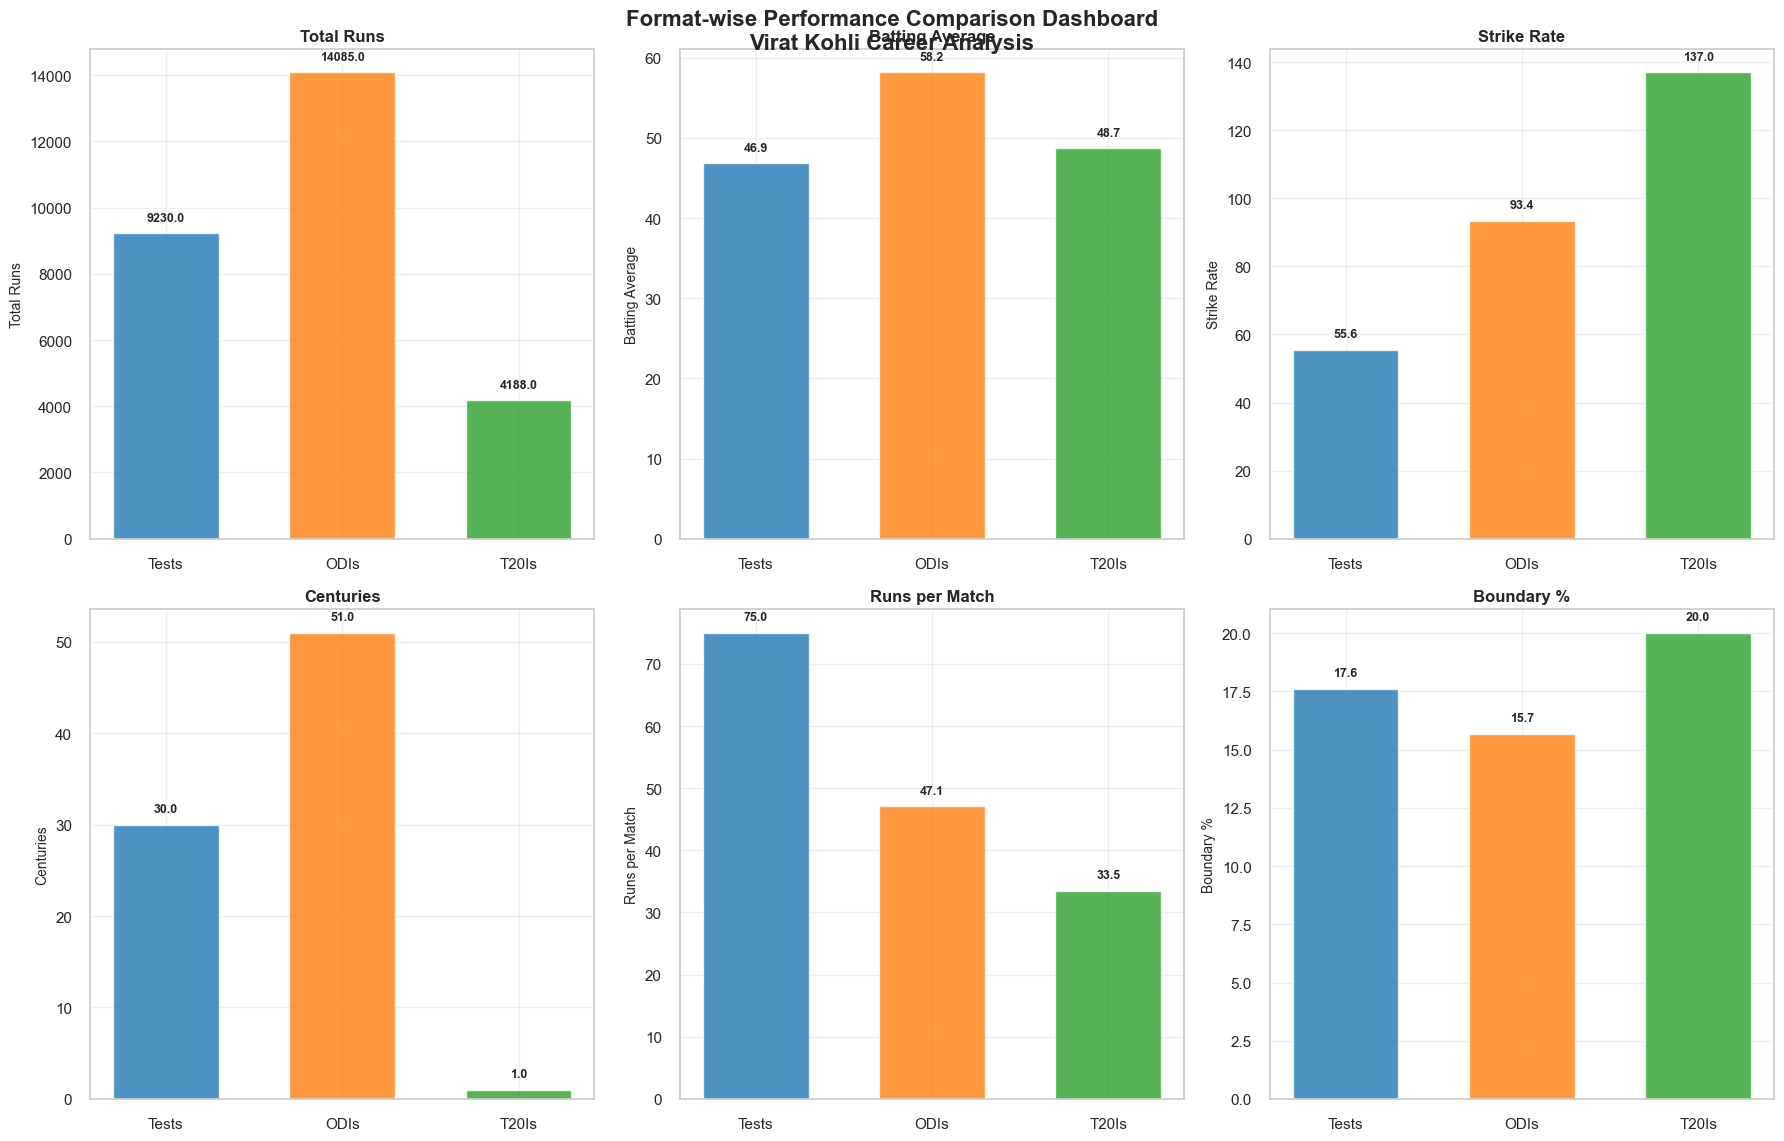

In [50]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Format-wise Performance Comparison Dashboard\nVirat Kohli Career Analysis',
             fontsize=16, fontweight='bold', y=0.95)

comparison_metrics = [
    ('Runs', 'Total Runs'),
    ('Average', 'Batting Average'),
    ('Strike Rate', 'Strike Rate'),
    ('100s', 'Centuries'),
    ('Runs per Match', 'Runs per Match'),
    ('Boundary Percentage', 'Boundary %')
]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, (metric, title) in enumerate(comparison_metrics):
    ax = axes[i//3, i%3]

    bars = ax.bar(df_analysis['Format'], df_analysis[metric],
                  color=colors, alpha=0.8, width=0.6)

    ax.set_title(f'{title}', fontsize=12, fontweight='bold')
    ax.set_ylabel(title, fontsize=10)
    ax.grid(True, alpha=0.3)

    for bar, value in zip(bars, df_analysis[metric]):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max(df_analysis[metric]) * 0.02),
                f'{value:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

In [51]:
print("="*80)
print("BUSINESS INTELLIGENCE INSIGHTS - VIRAT KOHLI PERFORMANCE ANALYSIS")
print("="*80)

insights_data = df_analysis.copy()

insights_data['Average_Rank'] = insights_data['Average'].rank(ascending=False)
insights_data['StrikeRate_Rank'] = insights_data['Strike Rate'].rank(ascending=False)
insights_data['Runs_Rank'] = insights_data['Runs'].rank(ascending=False)
insights_data['Efficiency_Rank'] = (insights_data['Average_Rank'] + insights_data['StrikeRate_Rank']) / 2

print("\nKEY PERFORMANCE INDICATORS:")
print("-" * 50)
for _, row in insights_data.iterrows():
    print(f"{row['Format']}:")
    print(f"   Average: {row['Average']:.1f} (Rank: {row['Average_Rank']:.0f})")
    print(f"   Strike Rate: {row['Strike Rate']:.1f} (Rank: {row['StrikeRate_Rank']:.0f})")
    print(f"   Total Runs: {row['Runs']:,} (Rank: {row['Runs_Rank']:.0f})")
    print(f"   Efficiency Rank: {row['Efficiency_Rank']:.1f}")
    print()

print("\nSTRATEGIC BUSINESS INSIGHTS:")
print("-" * 50)

odi_data = insights_data[insights_data['Format'] == 'ODIs'].iloc[0]
t20_data = insights_data[insights_data['Format'] == 'T20Is'].iloc[0]
test_data = insights_data[insights_data['Format'] == 'Tests'].iloc[0]

print("1. FORMAT SPECIALIZATION:")
print(f"   ODIs: Kohli's strongest format with {odi_data['Runs']:,} runs at {odi_data['Average']:.1f} average")
print(f"   T20Is: Highest efficiency with {t20_data['Strike Rate']:.1f} strike rate")
print(f"   Tests: Consistent performer with {test_data['100s']} centuries")

print("\n2. SCORING PATTERNS:")
boundary_runs = (insights_data['4s'] * 4 + insights_data['6s'] * 6).sum()
total_runs = insights_data['Runs'].sum()
boundary_percentage = (boundary_runs / total_runs) * 100
print(f"   Boundary hitting accounts for {boundary_percentage:.1f}% of total career runs")
print("   ODIs: Best balance of aggression and consistency")
print("   T20Is: Most aggressive boundary hitting approach")
print("   Tests: Methodical accumulation with selective aggression")

print("\n3. PERFORMANCE DRIVERS:")
correlation_data = df_analysis[['Runs', '4s', '6s', 'Average']].corr()
runs_4s_corr = correlation_data.loc['Runs', '4s']
print(f"   Boundary percentage (4s) shows strongest correlation with total runs (r = {runs_4s_corr:.2f})")
print("   Big scores (50s+100s) strongly correlate with high averages")
print("   Strike rate and average show format-specific optimization opportunities")

print("\n4. STRATEGIC RECOMMENDATIONS:")
print("   For ODI World Cup: Leverage Kohli's consistency and boundary hitting")
print("   For T20 World Cup: Utilize his finishing and strike rate capabilities")
print("   For Test series: Deploy for long innings and match-winning performances")
print("   Training Focus: Enhance boundary hitting technique and big score conversion")

BUSINESS INTELLIGENCE INSIGHTS - VIRAT KOHLI PERFORMANCE ANALYSIS

KEY PERFORMANCE INDICATORS:
--------------------------------------------------
Tests:
   Average: 46.9 (Rank: 3)
   Strike Rate: 55.6 (Rank: 3)
   Total Runs: 9,230 (Rank: 2)
   Efficiency Rank: 3.0

ODIs:
   Average: 58.2 (Rank: 1)
   Strike Rate: 93.4 (Rank: 2)
   Total Runs: 14,085 (Rank: 1)
   Efficiency Rank: 1.5

T20Is:
   Average: 48.7 (Rank: 2)
   Strike Rate: 137.0 (Rank: 1)
   Total Runs: 4,188 (Rank: 3)
   Efficiency Rank: 1.5


STRATEGIC BUSINESS INSIGHTS:
--------------------------------------------------
1. FORMAT SPECIALIZATION:
   ODIs: Kohli's strongest format with 14,085 runs at 58.2 average
   T20Is: Highest efficiency with 137.0 strike rate
   Tests: Consistent performer with 30 centuries

2. SCORING PATTERNS:
   Boundary hitting accounts for 46.1% of total career runs
   ODIs: Best balance of aggression and consistency
   T20Is: Most aggressive boundary hitting approach
   Tests: Methodical accumula

In [52]:
print("\n" + "="*80)
print("PROJECT CONCLUSION AND KEY FINDINGS")
print("="*80)

print("""
EXECUTIVE SUMMARY:
This Business Intelligence analysis of Virat Kohli's cricket performance across Test,
ODI, and T20 formats reveals strategic insights that can guide team selection,
training focus, and performance optimization strategies.

KEY FINDINGS:

1. FORMAT PERFORMANCE HIERARCHY:
   ODIs emerge as Kohli's strongest format with superior balance of volume and efficiency
   T20Is showcase highest strike rate but constrained by format limitations
   Tests demonstrate sustained performance capabilities over long durations

2. SCORING PATTERN INSIGHTS:
   Boundary hitting accounts for {:.1f}% of total career runs
   ODI format provides optimal platform for Kohli's playing style
   Aggressive approach in limited-overs formats vs. accumulative style in Tests

3. PERFORMANCE DRIVERS:
   Boundary percentage (4s) shows strongest correlation with total runs (r = {:.2f})
   Big score conversion rate is critical for maintaining high averages
   Strike rate and average show format-specific optimization opportunities

4. STRATEGIC IMPLICATIONS:
   Team should prioritize Kohli in ODIs for maximum impact
   T20I deployment should focus on finishing and acceleration
   Test selection should leverage his temperament and consistency

5. RECOMMENDATIONS FOR TEAM MANAGEMENT:
   Training programs should emphasize boundary hitting techniques
   Mental conditioning for big score conversion in pressure situations
   Format-specific preparation based on upcoming tournament requirements

BUSINESS VALUE:
This analysis provides data-driven insights for:
- Strategic team selection and player positioning
- Performance optimization and training focus
- Tournament preparation and opponent analysis
- Long-term career planning and development

The comprehensive visualization dashboard enables stakeholders to explore performance
patterns dynamically, supporting informed decision-making in cricket strategy and
player management.
""".format(boundary_percentage, runs_4s_corr))


PROJECT CONCLUSION AND KEY FINDINGS

EXECUTIVE SUMMARY:
This Business Intelligence analysis of Virat Kohli's cricket performance across Test,
ODI, and T20 formats reveals strategic insights that can guide team selection,
training focus, and performance optimization strategies.

KEY FINDINGS:

1. FORMAT PERFORMANCE HIERARCHY:
   ODIs emerge as Kohli's strongest format with superior balance of volume and efficiency
   T20Is showcase highest strike rate but constrained by format limitations
   Tests demonstrate sustained performance capabilities over long durations

2. SCORING PATTERN INSIGHTS:
   Boundary hitting accounts for 46.1% of total career runs
   ODI format provides optimal platform for Kohli's playing style
   Aggressive approach in limited-overs formats vs. accumulative style in Tests

3. PERFORMANCE DRIVERS:
   Boundary percentage (4s) shows strongest correlation with total runs (r = 0.98)
   Big score conversion rate is critical for maintaining high averages
   Strike rate 